Epoch 1/2
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.3596
Epoch 2/2
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2253
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step


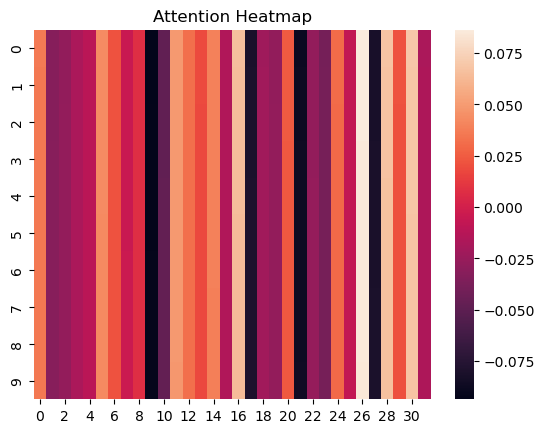

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.layers import Input, LSTM, Dense, Attention, Concatenate
from tensorflow.keras.models import Model

# 🔹 Dummy Data
X_enc = np.random.rand(200, 10, 1)
X_dec = np.random.rand(200, 10, 1)
y = np.random.rand(200, 10, 1)

# 🔹 Encoder
enc_input = Input(shape=(10, 1))
enc_out, h, c = LSTM(32, return_sequences=True, return_state=True)(enc_input)

# 🔹 Decoder
dec_input = Input(shape=(10, 1))
dec_out, _, _ = LSTM(32, return_sequences=True, return_state=True)(
    dec_input, initial_state=[h, c]
)

# 🔹 Attention
attn = Attention()([dec_out, enc_out])

# 🔹 Combine + Output
merged = Concatenate()([dec_out, attn])
output = Dense(1)(merged)

# 🔹 Model
model = Model([enc_input, dec_input], output)
model.compile(optimizer='adam', loss='mse')

# 🔹 Train
model.fit([X_enc, X_dec], y, epochs=2)

# 🔹 Attention Heatmap
attn_model = Model([enc_input, dec_input], attn)
weights = attn_model.predict([X_enc[:1], X_dec[:1]])

sns.heatmap(weights[0])
plt.title("Attention Heatmap")
plt.show()